In [1]:
# Librerias
import pandas as pd
import seaborn as sb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Dataset
matr= pd.read_csv("Dataset/MatriculacionStem.csv")
ingreso = pd.read_csv("Dataset/data_Proporcion de lugares ocupador por mujeres_FUENTE_CEPAL.csv")

In [3]:
print(matr.columns)

Index(['indicatorId', 'geoUnit', 'year', 'famale', 'male'], dtype='object')


In [4]:
matr.describe()

,year,famale,male
count,128.000000,128.000000,128.000000
mean,2019.312500,36.503451,63.496549
std,2.822156,10.709359,10.709359
min,2015.000000,16.666670,0.000000
25%,2017.000000,31.230591,58.266335
50%,2019.000000,35.437405,64.562595
75%,2022.000000,41.733665,68.769409
max,2024.000000,100.000000,83.333330


In [5]:
matri2022 = matr[matr['year'] == 2022]

In [6]:
print(matri2022)

            indicatorId geoUnit  year     famale       male
5    FGP.5T8.F500600700     ARG  2022  48.476681  51.523319
10   FGP.5T8.F500600700     BLZ  2022  46.530609  53.469391
19   FGP.5T8.F500600700     BRA  2022  31.872761  68.127239
28   FGP.5T8.F500600700     CHL  2022  20.935011  79.064989
46   FGP.5T8.F500600700     CRI  2022  35.521191  64.478809
59   FGP.5T8.F500600700     DOM  2022  30.060499  69.939501
67   FGP.5T8.F500600700     ECU  2022  29.627371  70.372629
86   FGP.5T8.F500600700     MEX  2022  33.673168  66.326832
94   FGP.5T8.F500600700     PAN  2022  41.666672  58.333328
108  FGP.5T8.F500600700     SLV  2022  34.368290  65.631710
116  FGP.5T8.F500600700     TTO  2022  42.502338  57.497662
123  FGP.5T8.F500600700     URY  2022  47.053452  52.946548
126  FGP.5T8.F500600700     VGB  2022  64.757713  35.242287


In [20]:
egreso = matr[matr['year'].between(2015, 2023)].copy()

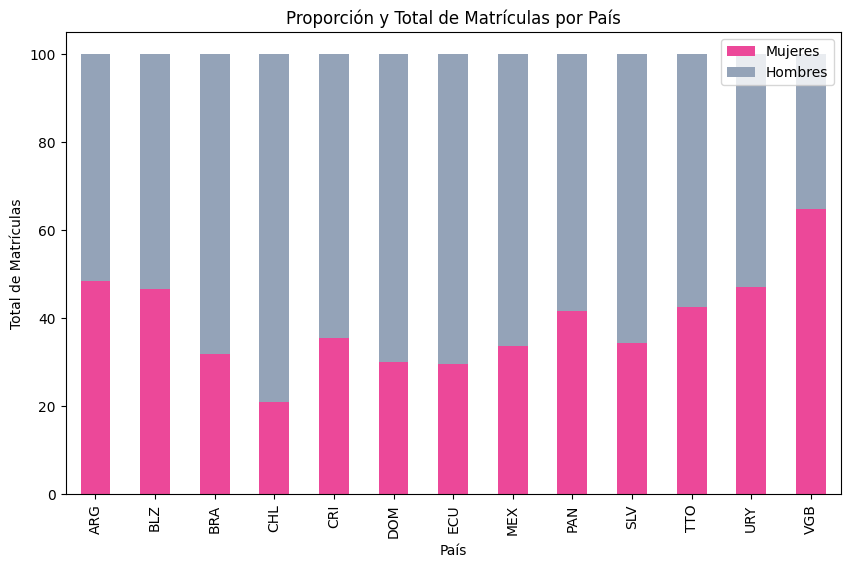

In [21]:
matri2022.plot(
    x="geoUnit", 
    y=["famale", "male"],
    kind="bar",           
    stacked=True,         
    figsize=(10, 6),      
    color=["#ec4899", "#94a3b8"] 
)

plt.title("Proporción y Total de Matrículas por País")
plt.xlabel("País")
plt.ylabel("Total de Matrículas")
plt.legend(["Mujeres", "Hombres"]) 
plt.show()


In [22]:

fig = px.bar(
    egreso, 
    x="geoUnit", 
    y=["famale", "male"], 
    barmode="group", # Esto pone las barras lado a lado
    color_discrete_sequence=["#ec4899", "#94a3b8"], # Tus colores exactos
    title="Comparativa Interactiva: Mujeres vs Hombres",
    labels={"value": "Número de Matrículas", "variable": "Género"}
)

fig.show()

In [23]:

fig = go.Figure()

for i, fila in egreso.iterrows():
    fig.add_trace(go.Scatter(
        x=[fila['famale'], fila['male']], 
        y=[fila['geoUnit'], fila['geoUnit']],
        mode='lines',
        line=dict(color='gray', width=2),
        showlegend=False
    ))

fig.add_trace(go.Scatter(
    x=egreso['famale'], 
    y=egreso['geoUnit'],
    mode='markers',
    name='Mujeres',
    marker=dict(color='#ec4899', size=12) 
))


fig.add_trace(go.Scatter(
    x=egreso['male'], 
    y=egreso['geoUnit'],
    mode='markers',
    name='Hombres',
    marker=dict(color='#94a3b8', size=12) 
))

fig.update_layout(
    title="Brecha de Matrícula STEM por País",
    xaxis_title="Número de Matrículas",
    yaxis_title="País",
    height=600
)
fig.show()

In [24]:
print(ingreso.columns)

Index(['indicator', 'Tipo de informe', 'Sexo', 'País__ESTANDAR',
       'Años__ESTANDAR', 'value', 'unit', 'notes_ids', 'source_id'],
      dtype='object')


In [25]:
ingreso.describe()

,Años__ESTANDAR,value,notes_ids,source_id
count,953.000000,953.000000,953.000000,953.000000
mean,2012.406086,21.704711,9354.684155,4043.145855
std,7.474034,11.854749,756.424796,704.802622
min,2000.000000,0.000000,8977.000000,3666.000000
25%,2006.000000,12.500000,8977.000000,3666.000000
50%,2012.000000,19.050000,8977.000000,3666.000000
75%,2019.000000,29.170000,8977.000000,3666.000000
max,2025.000000,55.740000,17122.000000,5414.000000


In [28]:
print(ingreso['País__ESTANDAR'].unique())

['América Central' 'Chile' 'Colombia' 'Costa Rica' 'Cuba' 'Dominica'
 'República Dominicana' 'Ecuador' 'El Salvador' 'Antigua y Barbuda'
 'El Caribe' 'Granada' 'Honduras' 'Argentina' 'Guatemala' 'Guyana'
 'México' 'Haití' 'Jamaica' 'América Latina y el Caribe' 'Bahamas'
 'Saint Kitts y Nevis' 'América del Sur' 'Barbados' 'Nicaragua' 'Panamá'
 'Paraguay' 'Perú' 'Santa Lucía' 'San Vicente y las Granadinas'
 'Bolivia (Estado Plurinacional de)' 'Suriname' 'Brasil'
 'Trinidad y Tabago' 'Belice' 'Uruguay'
 'Venezuela (República Bolivariana de)']


In [29]:
print(egreso['geoUnit'].unique())

['ABW' 'ARG' 'BLZ' 'BRA' 'CHL' 'COL' 'CRI' 'CUB' 'DOM' 'ECU' 'GRD' 'GTM'
 'HND' 'LCA' 'MEX' 'NIC' 'PAN' 'PER' 'PRI' 'SLV' 'SXM' 'TCA' 'TTO' 'URY'
 'VGB']


In [31]:
print(egreso['year'].unique())

[2016 2018 2019 2020 2021 2022 2023 2015 2017]


In [34]:
ingreso = ingreso[ingreso['Años__ESTANDAR'].between(2015, 2023)].copy()

In [35]:
print(ingreso['Años__ESTANDAR'].unique())

[2015 2016 2017 2018 2019 2020 2021 2022 2023]


In [36]:
print(matr['year'].unique())

[2016 2018 2019 2020 2021 2022 2023 2015 2024 2017]


In [37]:
#  Creamos el diccionario 
diccionario_paises = {
    'ARG': 'Argentina', 'BLZ': 'Belice', 'BRA': 'Brasil', 
    'CHL': 'Chile', 'COL': 'Colombia', 'CRI': 'Costa Rica', 
    'CUB': 'Cuba', 'DOM': 'República Dominicana', 'ECU': 'Ecuador', 
    'LCA': 'Santa Lucía', 'MEX': 'México', 'NIC': 'Nicaragua', 
    'PAN': 'Panamá', 'SLV': 'El Salvador', 'TTO': 'Trinidad y Tabago', 
    'URY': 'Uruguay'
}

egreso['País__ESTANDAR'] = egreso['geoUnit'].map(diccionario_paises)

In [38]:
# Filtramos ingreso 
ingreso_mujeres = ingreso[(ingreso['Años__ESTANDAR'] == 2022) & (ingreso['Sexo'] == 'Mujer')].copy()

# Filtramos egreso 
egreso_2022 = egreso[egreso['year'] == 2022].copy()

In [39]:
# inner join
comparativo_stem = pd.merge(
    ingreso_mujeres, 
    egreso_2022, 
    on='País__ESTANDAR', 
    how='inner'
)

# Renombramos las columnas 
comparativo_stem = comparativo_stem.rename(columns={
    'value': 'Total_Ingreso_Mujeres',
    'famale': 'Total_Egreso_Mujeres'
})


print(comparativo_stem[['País__ESTANDAR', 'Total_Ingreso_Mujeres', 'Total_Egreso_Mujeres']])

          País__ESTANDAR  Total_Ingreso_Mujeres  Total_Egreso_Mujeres
0                  Chile                  35.48             20.935011
1             Costa Rica                  45.61             35.521191
2   República Dominicana                  27.89             30.060499
3                Ecuador                  38.69             29.627371
4            El Salvador                  27.38             34.368290
5              Argentina                  44.75             48.476681
6                 México                  50.00             33.673168
7                 Panamá                  22.54             41.666672
8                 Brasil                  14.81             31.872761
9      Trinidad y Tabago                  26.19             42.502338
10                Belice                  12.50             46.530609
11               Uruguay                  25.25             47.053452


In [40]:


# Ordenamos igual que antes
df_grafica = comparativo_stem.sort_values(by='Total_Ingreso_Mujeres', ascending=False)

fig = px.bar(
    df_grafica, 
    x="País__ESTANDAR", 
    y=["Total_Ingreso_Mujeres", "Total_Egreso_Mujeres"],
    barmode="group",
    title="El Filtro Invisible: Ingreso vs Egreso de Mujeres en STEM año 2022",
    labels={"value": "Total de Mujeres", "País__ESTANDAR": "País", "variable": "Etapa"},
    color_discrete_sequence=["#fbcfe8", "#be185d"] # Rosa claro y oscuro
)

# Cambiamos los nombres de la leyenda
newnames = {'Total_Ingreso_Mujeres': 'Matriculadas', 'Total_Egreso_Mujeres': 'Graduadas'}
fig.for_each_trace(lambda t: t.update(name = newnames[t.name],
                                      legendgroup = newnames[t.name],
                                      hovertemplate = t.hovertemplate.replace(t.name, newnames[t.name])
                                     ))

fig.show()

In [41]:
egreso.head(5)

,indicatorId,geoUnit,year,famale,male,País__ESTANDAR
0,FGP.5T8.F500600700,ABW,2016,40.000000,60.000000,NaN
1,FGP.5T8.F500600700,ARG,2018,47.565578,52.434422,Argentina
2,FGP.5T8.F500600700,ARG,2019,48.353649,51.646351,Argentina
3,FGP.5T8.F500600700,ARG,2020,48.598209,51.401791,Argentina
4,FGP.5T8.F500600700,ARG,2021,47.937450,52.062550,Argentina


In [44]:
egreso[columnas_utiles]

,País__ESTANDAR,year,famale,male
0,NaN,2016,40.000000,60.000000
1,Argentina,2018,47.565578,52.434422
2,Argentina,2019,48.353649,51.646351
3,Argentina,2020,48.598209,51.401791
4,Argentina,2021,47.937450,52.062550
...,...,...,...,...
123,Uruguay,2022,47.053452,52.946548
124,Uruguay,2023,40.019520,59.980480
125,NaN,2021,49.407108,50.592892
126,NaN,2022,64.757713,35.242287


In [43]:
# Nota el DOBLE guion bajo antes de ESTANDAR
columnas_utiles = ['País__ESTANDAR', 'year', 'famale', 'male'] 

# Y actualizamos también la línea de limpieza para que coincida
datos_limpios = egreso[columnas_utiles].copy()
datos_limpios = datos_limpios.dropna(subset=['País__ESTANDAR'])

# El resto queda igual
datos_limpios = datos_limpios.rename(columns={
    'País__ESTANDAR': 'Pais',
    'year': 'Anio',
    'famale': 'Mujeres',
    'male': 'Hombres'
})

datos_limpios.to_json('grafica_comparativa_paises.json', orient='records')
print("¡JSON generado con éxito!")

¡JSON generado con éxito!


In [45]:
# 1. Filtramos el ingreso SOLO para mujeres (sin importar el año)
ingreso_mujeres = ingreso[ingreso['Sexo'] == 'Mujer'].copy()

# 2. HOMOLOGAMOS: Aseguramos que la columna del año se llame igual en ambas tablas
ingreso_mujeres = ingreso_mujeres.rename(columns={'Años__ESTANDAR': 'Anio'})
egreso_limpio = egreso.rename(columns={'year': 'Anio'})

# 3. EL MERGE MAESTRO: Unimos por País Y por Año para no duplicar datos
comparativo_stem_historico = pd.merge(
    ingreso_mujeres, 
    egreso_limpio, 
    on=['País__ESTANDAR', 'Anio'], 
    how='inner'
)

# 4. Renombramos columnas para el frontend
comparativo_stem_historico = comparativo_stem_historico.rename(columns={
    'País__ESTANDAR': 'Pais',
    'value': 'Ingreso_Mujeres',
    'famale': 'Egreso_Mujeres'
})

# 5. Limpiamos y seleccionamos solo lo necesario
columnas_finales = ['Pais', 'Anio', 'Ingreso_Mujeres', 'Egreso_Mujeres']
datos_finales = comparativo_stem_historico[columnas_finales].dropna()

# 6. Exportamos el JSON mágico
datos_finales.to_json('grafica3_filtro_invisible_historico.json', orient='records')

print("¡JSON multianual generado con éxito!")

¡JSON multianual generado con éxito!
